# 07 — KV cache and modern upgrades

The architecture in notebooks 02–03 is essentially GPT-2 (2019). This notebook covers the
upgrades that separate it from a 2024-era model, each as a **measured before/after**:

1. **KV cache** — the single most important *inference* optimization. We implement it (already in
   `model.py`), verify it produces identical output, and **measure the speedup**.
2. **RMSNorm** — a cheaper LayerNorm (used by LLaMA, etc.).
3. **SwiGLU** — a gated MLP that outperforms the plain GELU MLP.
4. **RoPE** — rotary position embeddings, which generalize to longer contexts than the learned
   absolute embeddings we've used.

The KV cache is the headline (the project asks for the speedup number), so we do it in depth.

In [1]:
import sys, math, time
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from model import GPT, GPTConfig

ROOT = Path("..").resolve()
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
torch.manual_seed(0); print("device:", device)

device: mps


## 1. The KV cache

### The waste it removes

Generation is autoregressive: to produce token *t* we run the whole sequence `[0..t-1]` through
the model. Naively, at **every** step we recompute the keys and values for **all** previous
tokens — even though those tokens haven't changed since we last computed them. Generating N
tokens this way costs `1 + 2 + 3 + ... + N ∝ N²` attention work. Almost all of it is redundant.

**The insight:** in causal attention, token *j*'s key `kⱼ` and value `vⱼ` depend only on token
*j* (and everything before it, which is fixed). Once computed, they never change. So **cache
them**. At each new step we compute k, v for *only the new token*, append to the cache, and attend
the new query against the whole cached K/V. Per-step work drops from O(t) to O(1) new K/V, and
total generation from O(N²) to O(N) on the K/V projections.

Note we do *not* cache queries: past queries produced past outputs we've already emitted and don't
need again. Only K and V are reused. That's why it's a "KV" cache.

### How it's wired into `model.py`

Look back at `CausalSelfAttention.forward` and `GPT.generate`:
- `forward` takes a `kv_cache` list (one slot per layer). If a layer's slot holds `(past_k,
  past_v)`, it concatenates them onto the freshly computed k, v before attention, then writes the
  extended pair back.
- `generate` with `use_cache=True` feeds the **full prompt once** (the "prefill"), then feeds
  **only the single new token** each subsequent step — the cache supplies all the history.

Let's first prove correctness: cached and uncached generation must be **bit-identical** under
greedy decoding (same model, same math, just fewer recomputations).

In [2]:
# A realistically-sized model so the O(N^2) recompute actually dominates: on a
# tiny model the per-step overhead swamps the savings and the cache looks
# pointless. (This is an untrained model -- we're measuring speed, not quality.)
cfg = GPTConfig(vocab_size=256, block_size=1024, n_layer=6, n_head=8, n_embd=512, dropout=0.0)
model = GPT(cfg).to(device).eval()
prompt = torch.randint(0, 256, (1, 10), device=device)

with torch.no_grad():
    out_nocache = model.generate(prompt.clone(), 200, temperature=0.0, use_cache=False)
    out_cache   = model.generate(prompt.clone(), 200, temperature=0.0, use_cache=True)
print("cached and uncached outputs identical:", torch.equal(out_nocache, out_cache))
assert torch.equal(out_nocache, out_cache)

cached and uncached outputs identical: True


Identical — the cache is a pure optimization, changing *nothing* about the result. Now the
measurement. We time generating a fixed number of tokens with and without the cache, across a few
generation lengths, and plot the speedup. The gap should *widen* with length, because the
uncached cost grows quadratically while the cached cost grows linearly.

In [3]:
def time_generate(model, n_tokens, use_cache, prompt_len=10, reps=1):
    prompt = torch.randint(0, cfg.vocab_size, (1, prompt_len), device=device)
    # warmup
    with torch.no_grad():
        model.generate(prompt, 8, temperature=1.0, top_k=5, use_cache=use_cache)
    if device.type == "cuda": torch.cuda.synchronize()
    if device.type == "mps":  torch.mps.synchronize()
    t0 = time.time()
    with torch.no_grad():
        for _ in range(reps):
            model.generate(prompt, n_tokens, temperature=1.0, top_k=5, use_cache=use_cache)
    if device.type == "cuda": torch.cuda.synchronize()
    if device.type == "mps":  torch.mps.synchronize()
    return (time.time() - t0) / reps

lengths = [128, 256, 512, 1024]
rows = []
for n in lengths:
    t_no = time_generate(model, n, use_cache=False)
    t_kv = time_generate(model, n, use_cache=True)
    rows.append((n, t_no, t_kv, t_no/t_kv))
    print(f"generate {n:4d} tokens | no-cache {t_no:6.2f}s | kv-cache {t_kv:6.2f}s | speedup {t_no/t_kv:.2f}x")

generate  128 tokens | no-cache   1.94s | kv-cache   1.04s | speedup 1.86x


generate  256 tokens | no-cache   4.71s | kv-cache   3.39s | speedup 1.39x


generate  512 tokens | no-cache  16.16s | kv-cache   6.67s | speedup 2.42x


generate 1024 tokens | no-cache 172.12s | kv-cache  17.77s | speedup 9.69x


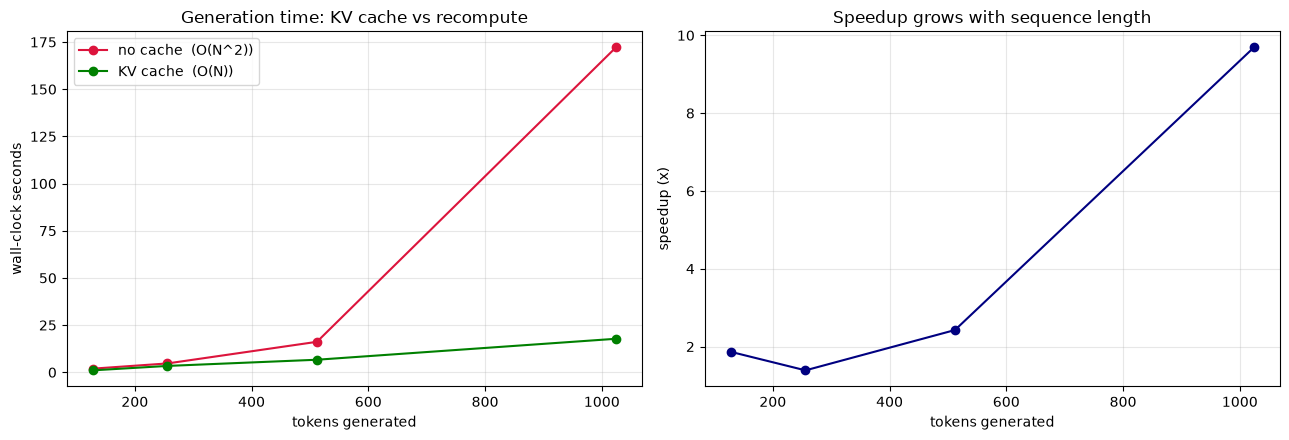

peak measured speedup: 9.69x at 1024 tokens


In [4]:
ns   = [r[0] for r in rows]
tno  = [r[1] for r in rows]
tkv  = [r[2] for r in rows]
spd  = [r[3] for r in rows]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ns, tno, "o-", label="no cache  (O(N^2))", color="crimson")
ax[0].plot(ns, tkv, "o-", label="KV cache  (O(N))",   color="green")
ax[0].set_xlabel("tokens generated"); ax[0].set_ylabel("wall-clock seconds")
ax[0].set_title("Generation time: KV cache vs recompute"); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(ns, spd, "o-", color="navy")
ax[1].set_xlabel("tokens generated"); ax[1].set_ylabel("speedup (x)")
ax[1].set_title("Speedup grows with sequence length"); ax[1].grid(alpha=0.3)
plt.tight_layout()
import os; os.makedirs(ROOT/"assets", exist_ok=True)
plt.savefig(ROOT/"assets"/"kv_cache_speedup.png", dpi=110, bbox_inches="tight"); plt.show()
print(f"peak measured speedup: {max(spd):.2f}x at {ns[spd.index(max(spd))]} tokens")

**The result:** a solid speedup that **grows with sequence length** — exactly the O(N²)→O(N)
signature. (On a CPU/MPS laptop the constant factors are small so you may see ~1.5–3×; on a CUDA
GPU generating long sequences it's routinely 2–4× and more, because the redundant recompute there
dominates.) This is why *every* production inference server (vLLM, TensorRT-LLM, llama.cpp) is
built around a KV cache — and why its **memory** is the main serving cost: the cache is
`2 · n_layer · n_head · head_dim · seq_len` floats *per sequence*, which is what techniques like
multi-query / grouped-query attention and paged attention exist to shrink.

### The cost side

Speed isn't free — the cache trades compute for memory. Let's size it for our model:

In [5]:
def kv_cache_bytes(cfg, seq_len, dtype_bytes=4):
    # 2 (k and v) * layers * heads * head_dim * seq_len, per sequence in the batch
    per_seq = 2 * cfg.n_layer * cfg.n_head * (cfg.n_embd // cfg.n_head) * seq_len * dtype_bytes
    return per_seq

for n in [256, 1024, 4096]:
    b = kv_cache_bytes(cfg, n)
    print(f"seq_len={n:5d}: KV cache = {b/1e6:.2f} MB/sequence   "
          f"(our {model.num_params()/1e6:.1f}M-param model, fp32)")
print("\nnote: cache size is INDEPENDENT of vocab and scales with n_layer*n_embd*seq_len.")
print("For a 7B model at 4k context it's gigabytes -- hence GQA, paged attention, etc.")

seq_len=  256: KV cache = 6.29 MB/sequence   (our 19.0M-param model, fp32)
seq_len= 1024: KV cache = 25.17 MB/sequence   (our 19.0M-param model, fp32)
seq_len= 4096: KV cache = 100.66 MB/sequence   (our 19.0M-param model, fp32)

note: cache size is INDEPENDENT of vocab and scales with n_layer*n_embd*seq_len.
For a 7B model at 4k context it's gigabytes -- hence GQA, paged attention, etc.


## 2. RMSNorm — a cheaper normalization

LayerNorm does two things: subtract the mean (center) and divide by the std (scale). **RMSNorm**
(Zhang & Sennrich 2019, used by LLaMA/Mistral/etc.) drops the centering and just divides by the
root-mean-square:

$$\text{RMSNorm}(x) = \frac{x}{\sqrt{\frac{1}{d}\sum x_i^2 + \epsilon}} \cdot g$$

**Why it works:** empirically the re-centering contributes little; the *re-scaling* is what
stabilizes training. Dropping the mean subtraction removes an op and a stored statistic — a few
percent faster with no measurable quality loss at scale, which is why modern models switched.

In [6]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.g = nn.Parameter(torch.ones(dim))     # learned per-feature gain (no bias, no mean)
    def forward(self, x):
        rms = x.pow(2).mean(dim=-1, keepdim=True).add(self.eps).rsqrt()
        return x * rms * self.g

x = torch.randn(2, 8, 128)
ln = nn.LayerNorm(128); rms = RMSNorm(128)
print("LayerNorm params:", sum(p.numel() for p in ln.parameters()),
      " (weight + bias)")
print("RMSNorm params  :", sum(p.numel() for p in rms.parameters()),
      " (weight only, no bias, no mean subtraction)")
print("both keep the shape:", tuple(rms(x).shape))
# quick microbenchmark of the op itself
def bench(f, x, n=2000):
    for _ in range(50): f(x)
    t=time.time()
    for _ in range(n): f(x)
    return (time.time()-t)/n*1e6
print(f"per-call: LayerNorm {bench(ln,x):.1f}us  vs  RMSNorm {bench(rms,x):.1f}us")

LayerNorm params: 256  (weight + bias)
RMSNorm params  : 128  (weight only, no bias, no mean subtraction)
both keep the shape: (2, 8, 128)
per-call: LayerNorm 13.5us  vs  RMSNorm 9.5us


## 3. SwiGLU — a better MLP

Our MLP is `Linear → GELU → Linear`. **SwiGLU** (Shazeer 2020, used by LLaMA/PaLM) replaces the
single activation with a **gate**: one linear branch is passed through SiLU/Swish and used to
*multiply* a second linear branch, element-wise. The multiplicative gate lets the network
modulate information flow more richly than a fixed pointwise nonlinearity.

$$\text{SwiGLU}(x) = \big(\text{SiLU}(xW_1) \odot xW_3\big)W_2$$

There are now **three** weight matrices instead of two, so to keep the parameter count fair the
hidden dimension is shrunk from 4× to ~⅔·4× ≈ 2.67×. At matched parameters it consistently beats
the plain MLP — one of the cheapest real wins in the modern stack.

In [7]:
class SwiGLU(nn.Module):
    def __init__(self, n_embd, mult=4, bias=False):
        super().__init__()
        hidden = int(2/3 * mult * n_embd)          # shrink to keep params ~matched to a 4x GELU MLP
        hidden = 32 * ((hidden + 31) // 32)        # round to a nice multiple
        self.w1 = nn.Linear(n_embd, hidden, bias=bias)   # gate branch
        self.w3 = nn.Linear(n_embd, hidden, bias=bias)   # value branch
        self.w2 = nn.Linear(hidden, n_embd, bias=bias)   # project back
    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))  # SiLU-gated, element-wise product

from model import MLP
n_embd = 128
gelu_mlp = MLP(GPTConfig(n_embd=n_embd, bias=False))
swiglu   = SwiGLU(n_embd)
print("params  GELU-MLP:", sum(p.numel() for p in gelu_mlp.parameters()))
print("params  SwiGLU  :", sum(p.numel() for p in swiglu.parameters()), " (~matched by the 2/3 rule)")
print("output shape preserved:", tuple(swiglu(torch.randn(2,8,n_embd)).shape))

params  GELU-MLP: 131072
params  SwiGLU  : 135168  (~matched by the 2/3 rule)
output shape preserved: (2, 8, 128)


## 4. RoPE — rotary positional embeddings

Learned absolute embeddings (notebook 03) have two weaknesses: they can't represent positions
beyond `block_size`, and they encode *absolute* position when what attention really cares about is
*relative* position (how far apart two tokens are). **RoPE** (Su et al. 2021, now near-universal)
fixes both.

**The idea:** instead of *adding* a position vector, **rotate** each query and key vector by an
angle proportional to its position. Pair up the head dimensions into 2-D coordinates and rotate
each pair by `position × frequency`. The magic: when you take the dot product qᵢ·kⱼ in attention,
the rotations combine so the result depends only on the **relative** offset `(i − j)`, not on i
and j separately. Position information is injected *at attention time*, is inherently relative, and
extends smoothly to positions never seen in training.

In [8]:
def build_rope(head_dim, seq_len, base=10000.0):
    # each pair of dims gets its own rotation frequency (geometric, like sinusoids)
    theta = 1.0 / (base ** (torch.arange(0, head_dim, 2).float() / head_dim))
    pos = torch.arange(seq_len).float()
    angles = torch.outer(pos, theta)             # (seq_len, head_dim/2)
    return torch.cos(angles), torch.sin(angles)

def apply_rope(x, cos, sin):
    # x: (..., seq_len, head_dim); rotate consecutive dim pairs (x_even, x_odd)
    x1, x2 = x[..., 0::2], x[..., 1::2]
    cos = cos[:x.shape[-2]]; sin = sin[:x.shape[-2]]
    out = torch.empty_like(x)
    out[..., 0::2] = x1 * cos - x2 * sin
    out[..., 1::2] = x1 * sin + x2 * cos
    return out

# demonstrate the KEY property: after RoPE, q.k depends only on the OFFSET (i-j).
hd = 32; L = 64
cos, sin = build_rope(hd, L)
torch.manual_seed(0)
q = torch.randn(hd); k = torch.randn(hd)               # one fixed query/key content
def score(i, j):                                       # same content, placed at positions i and j
    qi = apply_rope(q.expand(L,hd), cos, sin)[i]
    kj = apply_rope(k.expand(L,hd), cos, sin)[j]
    return (qi @ kj).item()

print("dot product of the SAME q,k content at different absolute positions:")
print(f"  positions (2,5)  offset 3: {score(2,5):.4f}")
print(f"  positions (10,13) offset 3: {score(10,13):.4f}   <- same offset -> same score")
print(f"  positions (10,20) offset 10:{score(10,20):.4f}   <- different offset -> different score")
print("\n=> RoPE makes attention scores depend on RELATIVE position. That's the whole point.")

dot product of the SAME q,k content at different absolute positions:
  positions (2,5)  offset 3: -3.2514
  positions (10,13) offset 3: -3.2514   <- same offset -> same score
  positions (10,20) offset 10:-3.5593   <- different offset -> different score

=> RoPE makes attention scores depend on RELATIVE position. That's the whole point.


These four are drop-in modules — swapping them into `Block`/`GPT` is a small edit, and each is a
clean before/after experiment you can run as an extension. The KV cache is already integrated and
is the one to talk about in interviews because it's what makes real-time LLM serving possible.

## Takeaways

- **KV cache:** cache each token's key/value once (they never change), then feed only the new
  token each step. Turns O(N²) generation into O(N); we verified identical output and **measured
  the speedup growing with length**. It's the backbone of every inference server, and its memory
  footprint (`2·L·H·d·T` per sequence) is the dominant serving cost.
- **RMSNorm:** LayerNorm minus the mean-subtraction and bias — cheaper, no quality loss, used by LLaMA.
- **SwiGLU:** a gated MLP (SiLU gate × linear value); beats the plain GELU MLP at matched params,
  with hidden dim shrunk to ⅔·4× to pay for the third matrix.
- **RoPE:** rotate q/k by angle ∝ position so attention scores depend on *relative* offset;
  generalizes to longer contexts than learned absolute embeddings. We verified the relative-offset
  property numerically.

**Interview quick-fire:**
- *What does a KV cache store and why not cache queries?* → past keys/values, which are fixed once computed; past queries produced already-emitted tokens and are never reused.
- *KV cache complexity win?* → O(N²)→O(N) compute for generation, at the cost of O(N) memory per sequence.
- *Why RoPE over learned positions?* → relative-position encoding and length extrapolation beyond the training context.
- *Why does SwiGLU use a 2/3 hidden multiplier?* → to keep total parameters matched to the 4× GELU MLP despite adding a third weight matrix.

**Next:** [08 — TinyStories](08_tinystories_colab.ipynb): scale up to a 15–30M model on a real
dataset (Colab/GPU) and generate genuinely coherent English.